<a href="https://colab.research.google.com/github/simar-rekhi/triton/blob/neel/Batch_Invariance_Matrix_Mult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



--- Testing D=256 ---
B=   1 | D=  256 | torch_diff=0.000000 | custom_diff=0.000000
B=   2 | D=  256 | torch_diff=5.734375 | custom_diff=0.000000
B=   4 | D=  256 | torch_diff=6.398438 | custom_diff=0.000000
B=   8 | D=  256 | torch_diff=6.503906 | custom_diff=0.000000
B=  16 | D=  256 | torch_diff=6.818359 | custom_diff=0.000000
B=  32 | D=  256 | torch_diff=3.053711 | custom_diff=0.000000
B=  64 | D=  256 | torch_diff=2.894531 | custom_diff=0.000000
B= 128 | D=  256 | torch_diff=2.805664 | custom_diff=0.000000
B= 256 | D=  256 | torch_diff=3.817383 | custom_diff=0.000000
B= 512 | D=  256 | torch_diff=3.790039 | custom_diff=0.000000
B=1024 | D=  256 | torch_diff=10.529297 | custom_diff=0.000000

--- Testing D=512 ---
B=   1 | D=  512 | torch_diff=0.000000 | custom_diff=0.000000
B=   2 | D=  512 | torch_diff=15.406250 | custom_diff=0.000000
B=   4 | D=  512 | torch_diff=16.992188 | custom_diff=0.000000
B=   8 | D=  512 | torch_diff=9.937500 | custom_diff=0.000000
B=  16 | D=  512 | to

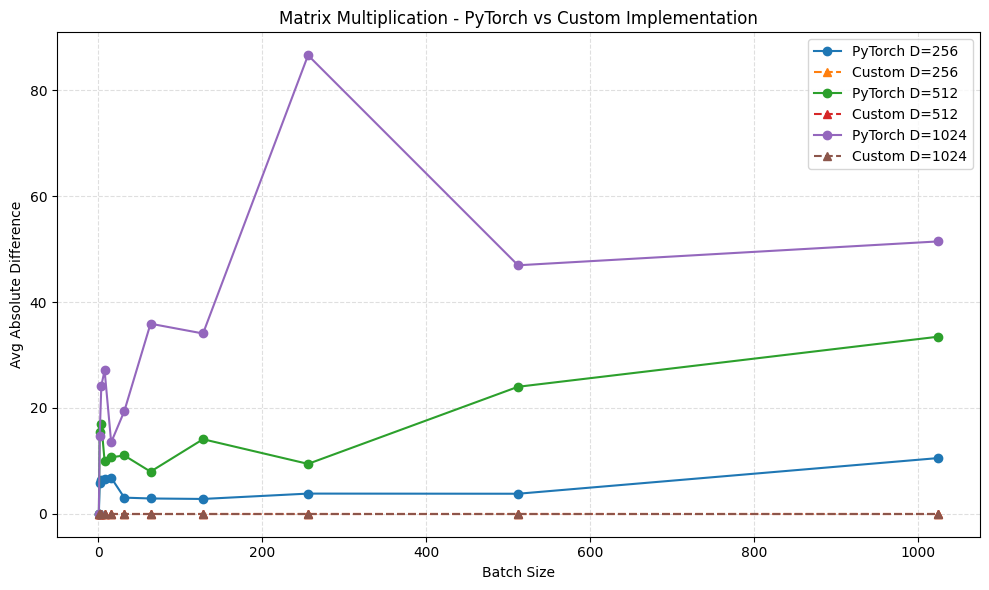

In [2]:
import torch
import matplotlib.pyplot as plt

torch.set_default_device("cuda")
torch.manual_seed(0)

def matmul(A, B):
    M = len(A)
    K = len(A[0])
    N = len(B[0])

    C = [[0.0 for _ in range(N)] for _ in range(M)]

    for i in range(M):
        for k in range(K):
            a_ik = A[i][k]
            Bk = B[k]
            Ci = C[i]
            for j in range(N):
                Ci[j] += a_ik * Bk[j]

    return C

def avg_diff(t1, t2):
    return (t1 - t2).abs().mean().item()

def test_matmul_batch_effect_pytorch(B, D, dtype=torch.float32):
    a = torch.linspace(-1000, 1000, B * D, device="cuda", dtype=dtype).reshape(B, D)
    b = torch.linspace(-1000, 1000, D * D, device="cuda", dtype=dtype).reshape(D, D)

    out_single = torch.mm(a[:1], b)
    out_batched = torch.mm(a, b)[:1]

    return avg_diff(out_single, out_batched)

def test_matmul_batch_effect_custom(B, D):
    a = torch.linspace(-1000, 1000, B * D).reshape(B, D).tolist()
    b = torch.linspace(-1000, 1000, D * D).reshape(D, D).tolist()

    a_single = [a[0]]

    out_single = matmul(a_single, b)
    out_batched = matmul(a, b)[0:1]

    t1 = torch.tensor(out_single, dtype=torch.float32)
    t2 = torch.tensor(out_batched, dtype=torch.float32)

    return avg_diff(t1, t2)

def run_experiments():
    batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
    dimensions = [256, 512, 1024]

    results_torch = {}
    results_custom = {}

    for D in dimensions:
        diffs_torch = []
        diffs_custom = []

        print(f"\n--- Testing D={D} ---")
        for B in batch_sizes:
            diff_torch = test_matmul_batch_effect_pytorch(B, D)
            diff_custom = test_matmul_batch_effect_custom(B, D)

            diffs_torch.append(diff_torch)
            diffs_custom.append(diff_custom)

            print(
                f"B={B:4d} | D={D:5d} | torch_diff={diff_torch:.6f} | custom_diff={diff_custom:.6f}"
            )

        results_torch[D] = diffs_torch
        results_custom[D] = diffs_custom

    return results_torch, results_custom, batch_sizes

def plot_results(results_torch, results_custom, batch_sizes):
    plt.figure(figsize=(10, 6))

    for D in results_torch.keys():
        plt.plot(
            batch_sizes,
            results_torch[D],
            marker="o",
            label=f"PyTorch D={D}",
        )
        plt.plot(
            batch_sizes,
            results_custom[D],
            marker="^",
            linestyle="--",
            label=f"Custom D={D}",
        )

    plt.title("Matrix Multiplication - PyTorch vs Custom Implementation")
    plt.xlabel("Batch Size")
    plt.ylabel("Avg Absolute Difference")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    results_torch, results_custom, batch_sizes = run_experiments()
    plot_results(results_torch, results_custom, batch_sizes)